In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [3]:
df = pd.read_csv("/content/drive/MyDrive/lab_data/project.csv")

df.head()

,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
0,84,30,36,7,3,72
1,91,24,38,6,3,56
2,73,29,26,7,3,56
3,80,36,35,7,3,74
4,84,31,37,8,3,66


In [ ]:
X = df[['Attendance (%)',
        'Internal Test 1 (out of 40)',
        'Internal Test 2 (out of 40)',
        'Assignment Score (out of 10)',
        'Daily Study Hours']]

y = df['Final Exam Marks (out of 100)']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

In [ ]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    score = r2_score(y_test, y_pred)

    results[name] = score

    print(name, ":", round(score, 4))

Linear Regression : 0.8297
Decision Tree : 0.5821
Random Forest : 0.7797
SVR : 0.7732
KNN : 0.7534


In [ ]:
best_algorithm = max(results, key=results.get)

print("Best Algorithm =", best_algorithm)

print("Best Accuracy =", round(results[best_algorithm], 4))

Best Algorithm = Linear Regression
Best Accuracy = 0.8297


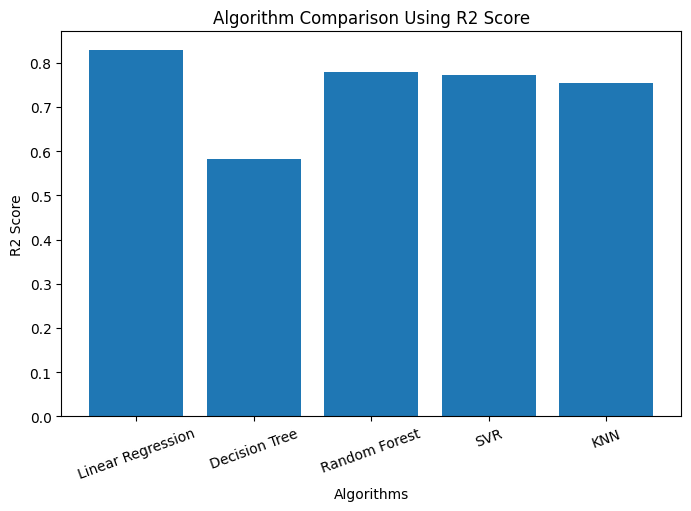

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results.keys(), results.values())

plt.title("Algorithm Comparison Using R2 Score")

plt.xlabel("Algorithms")

plt.ylabel("R2 Score")

plt.xticks(rotation=20)

plt.show()

In [ ]:
best_model = models[best_algorithm]

best_model.fit(X_train, y_train)

new_student = [[85, 32, 34, 9, 5]]

prediction = best_model.predict(new_student)

print("Predicted Final Marks =", round(prediction[0], 2))

Predicted Final Marks = 74.59


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
new_student = [[75, 28, 30, 8, 4]]
prediction = best_model.predict(new_student)

print("Predicted Final Marks =", prediction[0])

Predicted Final Marks = 59.23780029920965


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
